# Air Fryer Demand Estimation — Data Analyst Notebook

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

DATA_FILE = "air_fryers_clean_brand_year.csv"

if Path(DATA_FILE).exists():
    data_path = Path(DATA_FILE)
elif (Path("/mnt/data") / DATA_FILE).exists():
    data_path = Path("/mnt/data") / DATA_FILE
else:
    raise FileNotFoundError(f"Could not find {DATA_FILE}. Put it in the same folder as this notebook.")

df = pd.read_csv(data_path)
feature_cols = [
    "compact_share",
    "dual_basket_share",
    "oven_style_share",
    "rotisserie_share",
    "window_share",
]

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

df.head()


,category,year,brand,purchase_count,product_count,avg_price,avg_rating,compact_share,dual_basket_share,oven_style_share,rotisserie_share,window_share,market_purchases,brand_share,log_brand_share
0,air_fryers,2019,chefman,1146,10,72.963695,4.434119,1.000000,0.0,0.780977,0.243455,0.184119,15076,0.076015,-2.576826
1,air_fryers,2019,cosori,11,2,159.990000,4.581818,1.000000,0.0,0.090909,0.090909,0.000000,15076,0.000730,-7.222964
2,air_fryers,2019,cuisinart,1616,22,229.465274,4.481312,0.993812,0.0,0.889851,0.000000,0.000000,15076,0.107190,-2.233150
3,air_fryers,2019,dash,3011,19,55.176333,4.390767,1.000000,0.0,0.973431,0.000000,0.000000,15076,0.199721,-1.610832
4,air_fryers,2019,gowise usa,4405,45,83.575551,4.552259,0.999773,0.0,0.129398,0.128490,0.000000,15076,0.292186,-1.230364


## 1. Data validation

In [11]:
print("Rows, columns:", df.shape)
print("Number of brands:", df["brand"].nunique())
print("Brands:", sorted(df["brand"].unique()))
print("Years:", sorted(df["year"].unique()))

share_check = df.groupby("year")["brand_share"].sum().reset_index(name="share_sum")
display(share_check)

brand_year_count = df.groupby("year")["brand"].nunique().reset_index(name="brands_per_year")
display(brand_year_count)

Rows, columns: (50, 15)
Number of brands: 10
Brands: ['chefman', 'cosori', 'cuisinart', 'dash', 'gowise usa', 'instant_pot', 'ninja', 'nuwave', 'oster', 'ultrean']
Years: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]


,year,share_sum
0,2019,1.0
1,2020,1.0
2,2021,1.0
3,2022,1.0
4,2023,1.0


,year,brands_per_year
0,2019,10
1,2020,10
2,2021,10
3,2022,10
4,2023,10


### Interpretation: data validation

The dataset is already at the **brand-year** level. It contains **50 rows**, which equals **10 brands × 5 years**. The 10 brands are: chefman, cosori, cuisinart, dash, gowise usa, instant_pot, ninja, nuwave, oster, ultrean. The years are **2019–2023**.

The brand shares sum to **1.0 within each year**, which means the cleaned file is normalized within the included air fryer brands. That is important because the later demand model uses `log_brand_share` as the outcome, so shares need to be valid and positive.

## 2. Brand summary table

In [12]:
brand_summary = (
    df.groupby("brand")
      .agg(
          avg_price=("avg_price", "mean"),
          avg_rating=("avg_rating", "mean"),
          avg_share=("brand_share", "mean"),
          total_purchases=("purchase_count", "sum"),
          product_count=("product_count", "sum"),
          compact_share=("compact_share", "mean"),
          dual_basket_share=("dual_basket_share", "mean"),
          oven_style_share=("oven_style_share", "mean"),
          rotisserie_share=("rotisserie_share", "mean"),
          window_share=("window_share", "mean"),
      )
      .sort_values("avg_share", ascending=False)
)

display(brand_summary.round(3))

,avg_price,avg_rating,avg_share,total_purchases,product_count,compact_share,dual_basket_share,oven_style_share,rotisserie_share,window_share
brand,,,,,,,,,,
ninja,145.343,4.742,0.192,20074,211,0.992,0.002,0.100,0.000,0.000
instant_pot,104.461,4.559,0.175,19426,169,0.860,0.000,0.675,0.102,0.003
gowise usa,87.455,4.577,0.138,14962,168,1.000,0.000,0.184,0.184,0.001
dash,57.479,4.476,0.098,10295,121,0.999,0.000,0.890,0.000,0.000
chefman,90.938,4.428,0.095,9437,68,0.962,0.013,0.597,0.370,0.363
ultrean,78.115,4.673,0.092,11914,28,1.000,0.000,0.830,0.000,0.000
cuisinart,223.947,4.439,0.086,9676,164,0.996,0.000,0.913,0.000,0.000
nuwave,137.024,4.390,0.051,5741,96,0.995,0.007,0.543,0.027,0.000
cosori,114.268,4.656,0.049,4147,38,0.997,0.000,0.030,0.024,0.000


### Interpretation: brand-level market position

The largest average shares belong to **ninja (19.2%), instant_pot (17.5%), gowise usa (13.8%)**. That suggests the market is not evenly split: a few brands capture a much larger portion of observed purchases.

The most expensive brands on average are **cuisinart ($223.95), oster ($189.03), ninja ($145.34)**, while the lowest-priced brands are **dash ($57.48), ultrean ($78.11), gowise usa ($87.45)**. This points to some brand positioning differences, with Cuisinart/Oster/Ninja positioned more toward higher-priced products and Dash/Ultrean/Gowise USA positioned more toward lower or mid-priced products.

Ratings are relatively high across the market, but the highest average ratings are **ninja (4.742), ultrean (4.673), cosori (4.656)**. Because ratings do not vary as much as prices or shares, ratings alone probably do not explain all market-share differences.

## 3. Average price over time

brand,chefman,cosori,cuisinart,dash,gowise usa,instant_pot,ninja,nuwave,oster,ultrean
year,,,,,,,,,,
2019,72.96,159.99,229.47,55.18,83.58,78.02,112.16,151.10,191.94,80.62
2020,97.43,115.65,227.91,58.39,86.95,120.05,140.45,119.90,185.60,76.84
2021,92.08,97.42,224.30,57.73,84.63,113.64,166.68,136.04,184.62,76.80
2022,98.44,97.87,223.53,57.15,86.32,106.08,156.38,144.99,191.49,78.27
2023,93.78,100.41,214.53,58.95,95.80,104.52,151.05,133.10,191.52,78.04


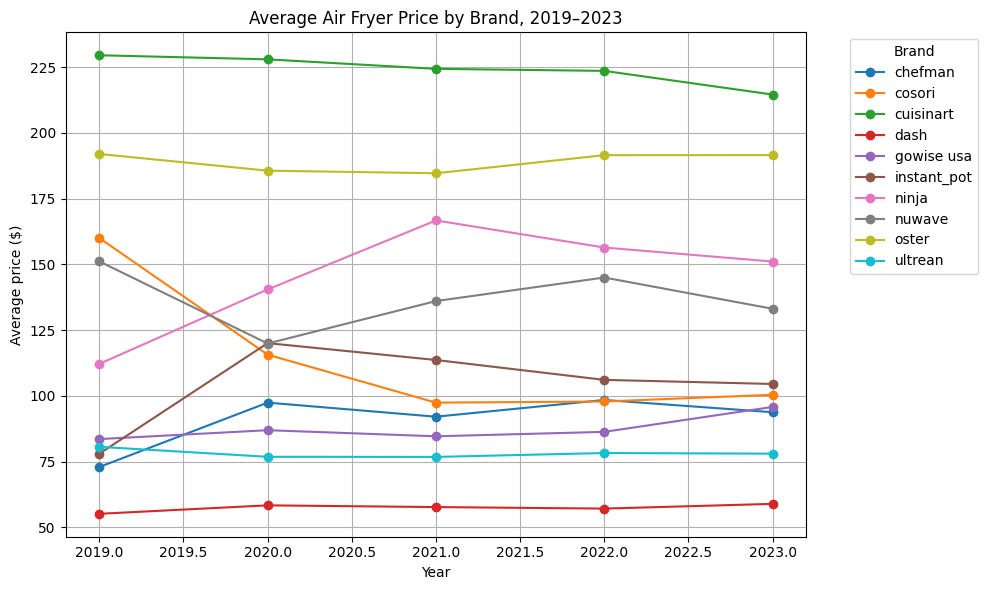

In [13]:
price_pivot = df.pivot(index="year", columns="brand", values="avg_price")
display(price_pivot.round(2))

ax = price_pivot.plot(marker="o")
ax.set_title("Average Air Fryer Price by Brand, 2019–2023")
ax.set_xlabel("Year")
ax.set_ylabel("Average price ($)")
ax.legend(title="Brand", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Interpretation: price trends

Prices differ a lot by brand. Cuisinart and Oster are consistently among the highest-priced brands, while Dash is consistently one of the cheapest. Ninja is also relatively expensive, but unlike Cuisinart and Oster, it also has a large market share. This suggests Ninja may be combining premium pricing with strong consumer demand.

The market does not look like every brand moves together perfectly over time. Some brands have sharper changes than others, which is useful because the demand model needs variation in price and characteristics to estimate relationships.

## 4. Average rating over time

brand,chefman,cosori,cuisinart,dash,gowise usa,instant_pot,ninja,nuwave,oster,ultrean
year,,,,,,,,,,
2019,4.434,4.582,4.481,4.391,4.552,4.364,4.779,4.322,4.381,4.618
2020,4.356,4.662,4.461,4.490,4.579,4.596,4.753,4.447,4.385,4.680
2021,4.459,4.679,4.450,4.506,4.590,4.598,4.725,4.422,4.411,4.688
2022,4.453,4.685,4.414,4.497,4.596,4.614,4.730,4.363,4.369,4.690
2023,4.438,4.674,4.389,4.498,4.567,4.625,4.723,4.394,4.397,4.687


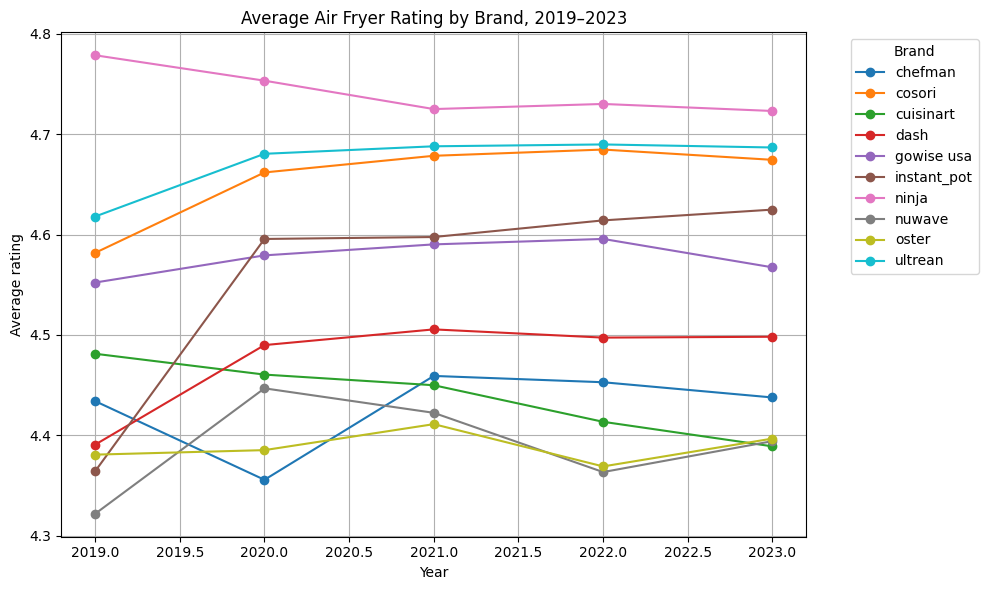

In [14]:
rating_pivot = df.pivot(index="year", columns="brand", values="avg_rating")
display(rating_pivot.round(3))

ax = rating_pivot.plot(marker="o")
ax.set_title("Average Air Fryer Rating by Brand, 2019–2023")
ax.set_xlabel("Year")
ax.set_ylabel("Average rating")
ax.legend(title="Brand", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Interpretation: rating trends

Ratings are generally clustered in the mid-to-high 4-star range, so the market appears to be mostly made up of well-reviewed products. Ninja, Ultrean, and Cosori tend to be near the top. Oster and Nuwave tend to have lower average ratings.

Since ratings are close together, small rating differences may still matter, but price, brand reputation, and product type likely play a bigger role in explaining share differences.

## 5. Market share over time

brand,chefman,cosori,cuisinart,dash,gowise usa,instant_pot,ninja,nuwave,oster,ultrean
year,,,,,,,,,,
2019,0.076,0.001,0.107,0.200,0.292,0.016,0.193,0.032,0.034,0.050
2020,0.058,0.009,0.102,0.101,0.170,0.143,0.166,0.079,0.014,0.157
2021,0.084,0.035,0.087,0.083,0.116,0.200,0.182,0.051,0.024,0.138
2022,0.117,0.073,0.077,0.051,0.058,0.287,0.199,0.034,0.026,0.078
2023,0.140,0.127,0.056,0.055,0.053,0.229,0.218,0.056,0.026,0.040


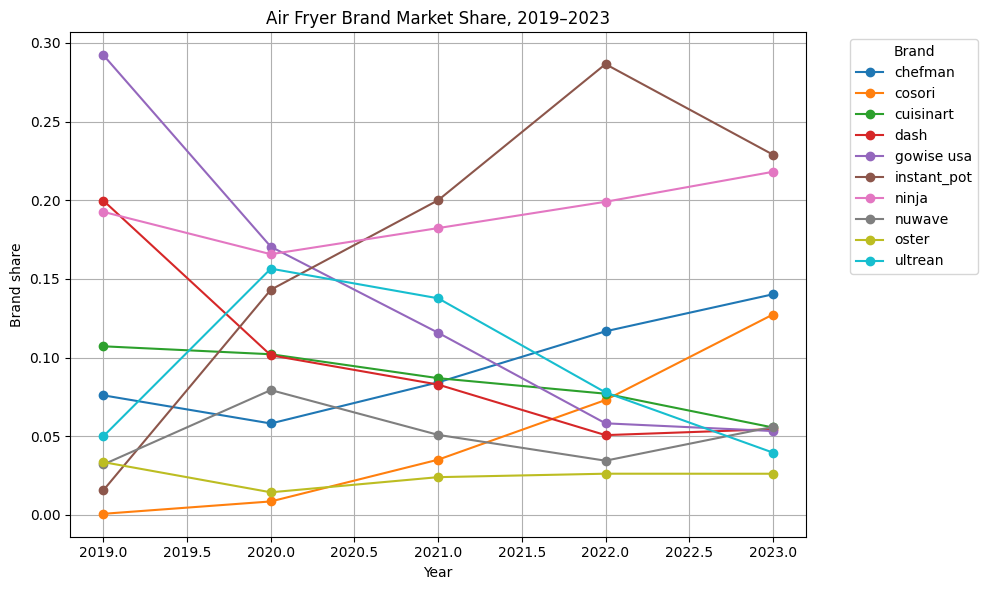

In [15]:
share_pivot = df.pivot(index="year", columns="brand", values="brand_share")
display(share_pivot.round(3))

ax = share_pivot.plot(marker="o")
ax.set_title("Air Fryer Brand Market Share, 2019–2023")
ax.set_xlabel("Year")
ax.set_ylabel("Brand share")
ax.legend(title="Brand", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Interpretation: market-share trends

Ninja and Instant Pot are consistently important brands, and Gowise USA starts with a very high share in 2019 before becoming less dominant later. Cosori grows sharply by 2023, while Dash declines from its 2019 position. This means the market does not look completely stable over time; there is meaningful brand movement.

For a business audience, the main takeaway is that brand strength changes over time. A pricing or product strategy that worked in 2019 may not work the same way by 2023.

## 6. Product characteristics and specialization

,market_average
compact_share,0.980
oven_style_share,0.563
rotisserie_share,0.071
window_share,0.037
dual_basket_share,0.002


,compact_share,dual_basket_share,oven_style_share,rotisserie_share,window_share
brand,,,,,
cuisinart,0.996,0.000,0.913,0.000,0.000
dash,0.999,0.000,0.890,0.000,0.000
oster,1.000,0.000,0.865,0.000,0.000
ultrean,1.000,0.000,0.830,0.000,0.000
instant_pot,0.860,0.000,0.675,0.102,0.003
chefman,0.962,0.013,0.597,0.370,0.363
nuwave,0.995,0.007,0.543,0.027,0.000
gowise usa,1.000,0.000,0.184,0.184,0.001
ninja,0.992,0.002,0.100,0.000,0.000


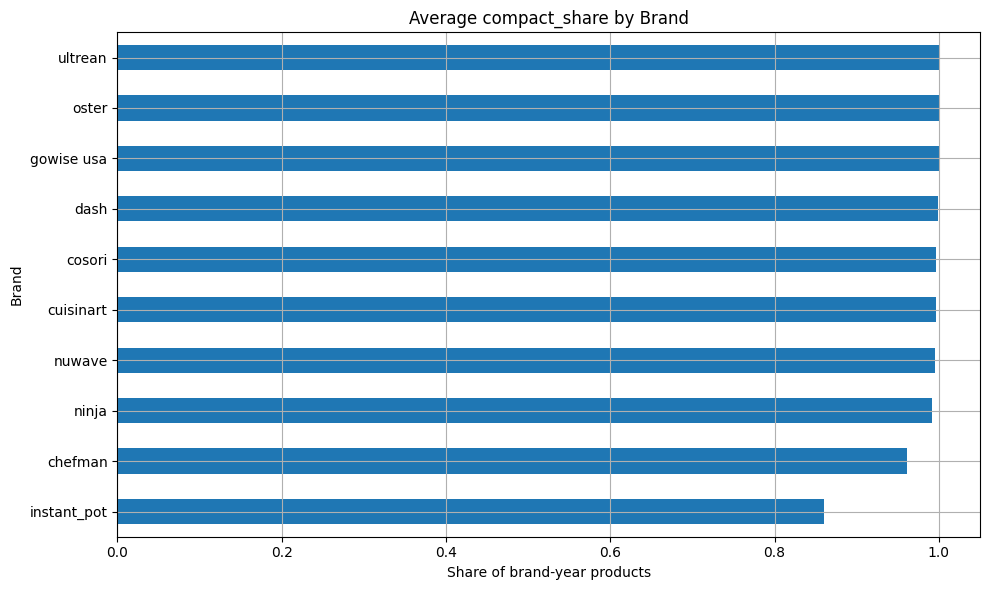

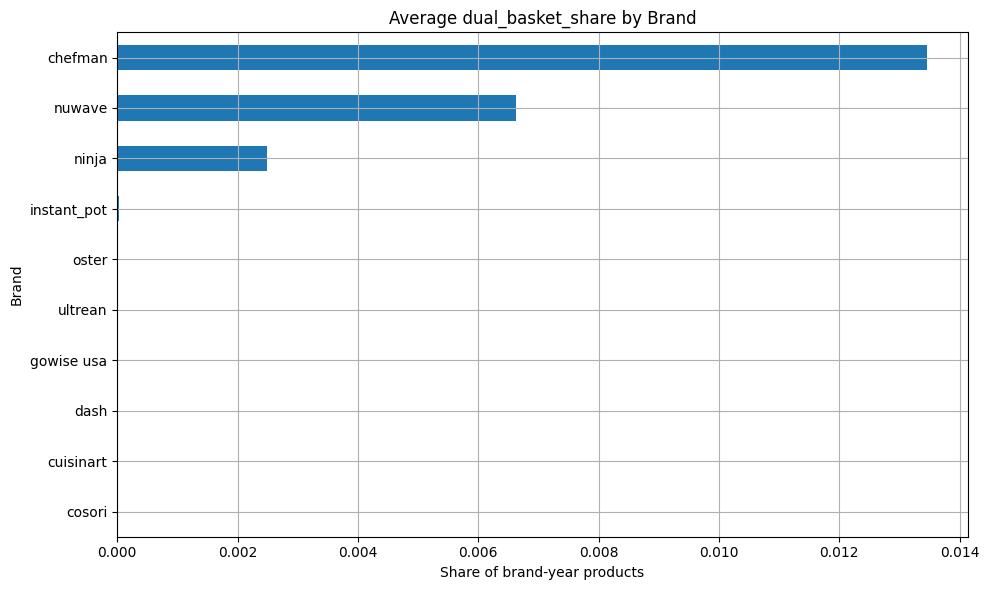

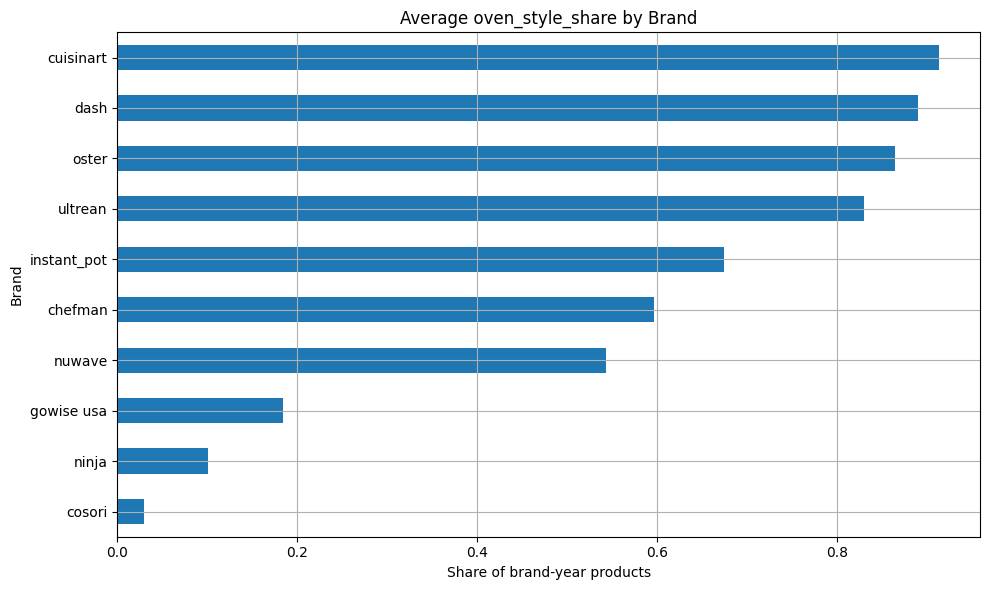

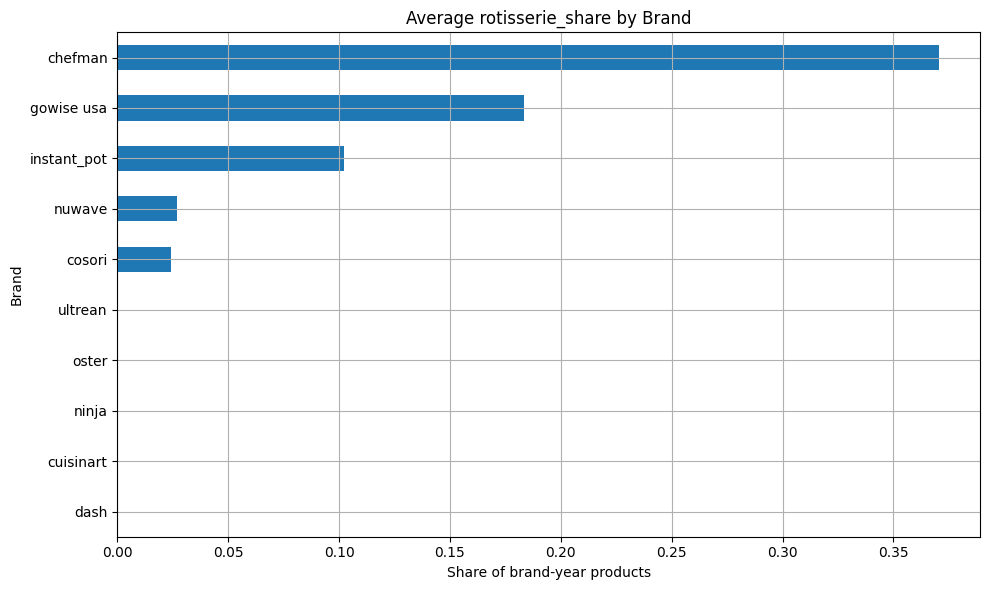

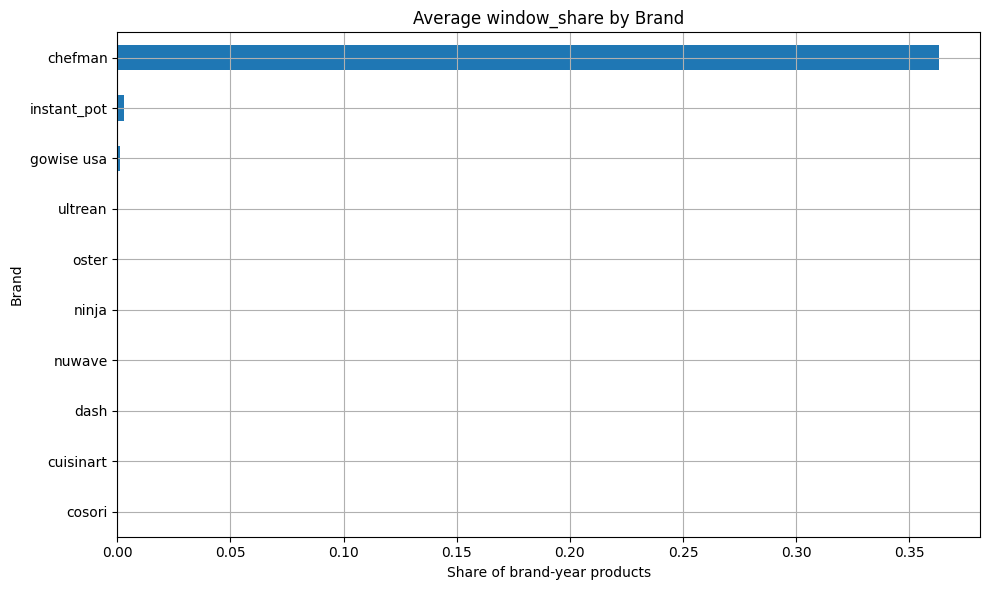

In [16]:
feature_means = df[feature_cols].mean().sort_values(ascending=False)
display(feature_means.to_frame("market_average").round(3))

brand_features = brand_summary[feature_cols].sort_values("oven_style_share", ascending=False)
display(brand_features.round(3))

for col in feature_cols:
    ax = df.groupby("brand")[col].mean().sort_values().plot(kind="barh")
    ax.set_title(f"Average {col} by Brand")
    ax.set_xlabel("Share of brand-year products")
    ax.set_ylabel("Brand")
    plt.tight_layout()
    plt.show()

### Interpretation: product characteristics

The most common feature is **compact_share**, with an overall average of about **0.98**. The next most common is **oven_style_share**, around **0.56**. Rare features are **dual_basket_share** at about **0.002**, **window_share** at about **0.037**, and **rotisserie_share** at about **0.071**.

There is some evidence of specialization. Cuisinart, Dash, and Oster lean heavily toward oven-style products. Chefman stands out for window and rotisserie features. Gowise USA and Instant Pot also show more rotisserie presence than most brands. This matters because two air fryer brands may not be competing only on price; they may be selling somewhat different product types.

## 7. Overall Data Analyst conclusion

From the EDA, the air fryer market looks like a mix of premium brands, value brands, and feature-specialized brands. **Ninja and Instant Pot** appear especially strong because they combine large market shares with solid ratings. **Cuisinart and Oster** are expensive, but their average market shares are smaller, which may suggest a more premium or niche position. **Dash** is cheaper and had a stronger early share, but its share declines over time. **Cosori** grows noticeably by 2023.

The market is not perfectly stable: brand shares shift across years, especially for Gowise USA, Cosori, Dash, and Ninja. That makes the market useful for demand estimation because there is variation in price, share, ratings, and product characteristics across brands and time.